  Fire & Smoke Detection — DSP Project

  Fire  pixels (before texture): 2427
  Fire  pixels (after texture) : 2427  (wall removed)
  Smoke pixels detected        : 2280
  Fire  accuracy               : 99.91%
  Smoke accuracy               : 98.68%


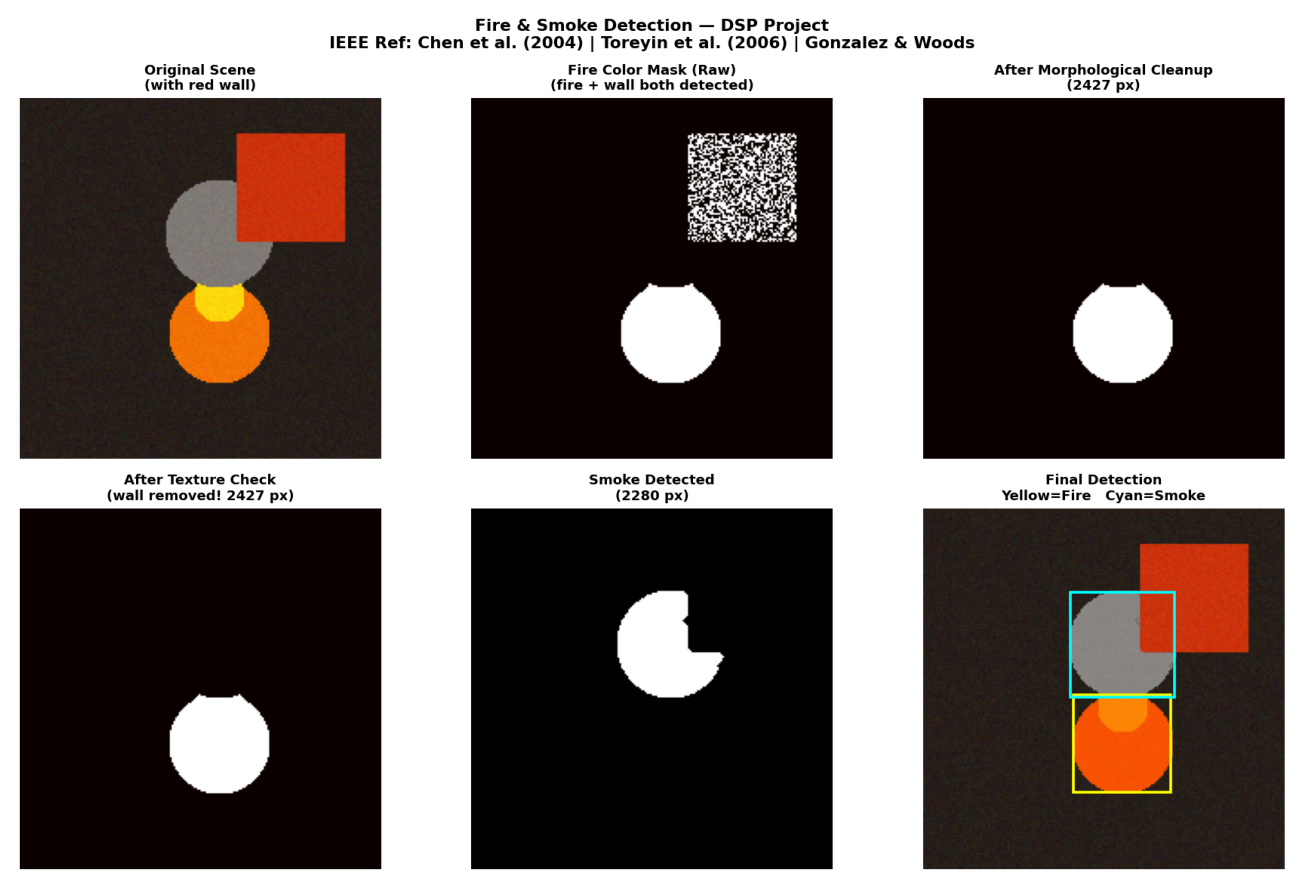

Saved as fire_detection.png

Done!


In [1]:
"""
Fire & Smoke Detection using DSP Techniques
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label, binary_opening, binary_closing

np.random.seed(7)

# 1.Create a synthetic fire scene
def create_scene(size=200):
    scene = np.zeros((size, size, 3))
    cx, cy = 110, 130
    Y, X = np.ogrid[:size, :size]

    # Dark background
    scene[:, :] = [0.15, 0.12, 0.10]

    # Fire region — red/orange
    fire = (X - cx)**2 + (Y - cy)**2 < 28**2
    scene[fire] = [0.95, 0.45, 0.02]

    # Fire tip — bright yellow
    tip = (X - cx)**2 + (Y - (cy - 20))**2 < 14**2
    scene[tip] = [1.0, 0.85, 0.05]

    # Smoke — gray cloud above fire
    smoke = (X - cx)**2 + (Y - (cy - 55))**2 < 30**2
    scene[smoke] = [0.50, 0.48, 0.46]

    # Red wall patch — simulates a false positive
    scene[20:80, 120:180] = [0.80, 0.20, 0.05]

    # Slight noise to simulate camera
    scene = np.clip(scene + np.random.normal(0, 0.02, scene.shape), 0, 1)

    return scene, fire, smoke

#2.Detect fire pixels using color rules─
def detect_fire(img):
    """
    Fire rule (IEEE Chen 2004):
    Red is dominant, Green is medium, Blue is low → R > G > B
    """
    R, G, B = img[:,:,0], img[:,:,1], img[:,:,2]
    mask = (R > 0.6) & (G > 0.2) & (B < 0.35) & (R > G) & (G > B)
    return mask.astype(np.uint8)

#3.Detect smoke pixels using color rules
def detect_smoke(img):
    """
    Smoke rule: R ≈ G ≈ B (grayish) with medium brightness
    """
    R, G, B = img[:,:,0], img[:,:,1], img[:,:,2]
    gray_diff  = (np.abs(R - G) < 0.12) & (np.abs(R - B) < 0.12)
    brightness = (R + G + B) / 3
    mask = gray_diff & (brightness > 0.3) & (brightness < 0.65)
    return mask.astype(np.uint8)

# 4.Clean mask using morphological operations
def clean_mask(mask):
    mask = binary_opening(mask.astype(bool), iterations=2)
    mask = binary_closing(mask.astype(bool), iterations=2)
    return mask.astype(np.uint8)

#5.Texture check to remove false positives
def check_texture(img, mask, threshold=0.003):
    # Convert to grayscale for texture measurement
    gray = 0.299*img[:,:,0] + 0.587*img[:,:,1] + 0.114*img[:,:,2]

    # Label each connected region separately
    labeled, num = label(mask)
    result = np.zeros_like(mask)

    for i in range(1, num + 1):
        region_pixels = gray[labeled == i]
        variance = np.var(region_pixels)
        if variance >= threshold:        # high variance → fire-like texture
            result[labeled == i] = 1     # keep this region
        
    return result

#6. Get bounding box around largest detected region 
def get_bbox(mask):
    labeled, num = label(mask)
    if num == 0:
        return None
    sizes   = [np.sum(labeled == i) for i in range(1, num + 1)]
    largest = np.argmax(sizes) + 1
    rows, cols = np.where(labeled == largest)
    return cols.min(), rows.min(), cols.max() - cols.min(), rows.max() - rows.min()

#7. Plot all results
def plot_results(scene, fire_mask, fire_clean, fire_texture, smoke_clean, f_box, s_box):
    fig, axes = plt.subplots(2, 3, figsize=(14, 9))
    fig.suptitle("Fire & Smoke Detection — DSP Project\n"
                 "IEEE Ref: Chen et al. (2004) | Toreyin et al. (2006) | Gonzalez & Woods",
                 fontsize=12, fontweight='bold')

    # Row 1
    axes[0][0].imshow(scene)
    axes[0][0].set_title("Original Scene\n(with red wall)", fontsize=10)
    axes[0][0].axis('off')

    axes[0][1].imshow(fire_mask, cmap='hot')
    axes[0][1].set_title(f"Fire Color Mask (Raw)\n(fire + wall both detected)", fontsize=10)
    axes[0][1].axis('off')

    axes[0][2].imshow(fire_clean, cmap='hot')
    axes[0][2].set_title(f"After Morphological Cleanup\n({fire_clean.sum()} px)", fontsize=10)
    axes[0][2].axis('off')

    # Row 2
    axes[1][0].imshow(fire_texture, cmap='hot')
    axes[1][0].set_title(f"After Texture Check\n(wall removed! {fire_texture.sum()} px)", fontsize=10)
    axes[1][0].axis('off')

    axes[1][1].imshow(smoke_clean, cmap='gray')
    axes[1][1].set_title(f"Smoke Detected\n({smoke_clean.sum()} px)", fontsize=10)
    axes[1][1].axis('off')

    # Final overlay
    ax = axes[1][2]
    ax.imshow(scene)
    fire_ov  = np.zeros((*scene.shape[:2], 4))
    smoke_ov = np.zeros((*scene.shape[:2], 4))
    fire_ov[fire_texture > 0]  = [1.0, 0.2, 0.0, 0.5]
    smoke_ov[smoke_clean > 0]  = [0.6, 0.6, 0.6, 0.4]
    ax.imshow(fire_ov)
    ax.imshow(smoke_ov)
    if f_box:
        x, y, w, h = f_box
        ax.add_patch(plt.Rectangle((x, y), w, h, edgecolor='yellow', facecolor='none', lw=2))
    if s_box:
        x, y, w, h = s_box
        ax.add_patch(plt.Rectangle((x, y), w, h, edgecolor='cyan', facecolor='none', lw=2))
    ax.set_title("Final Detection\nYellow=Fire   Cyan=Smoke", fontsize=10)
    ax.axis('off')

    plt.tight_layout()
    plt.savefig('fire_detection.png', dpi=130, bbox_inches='tight')
    plt.close()

    img = plt.imread('fire_detection.png')
    plt.figure(figsize=(14, 9))
    plt.imshow(img)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    print("Saved as fire_detection.png")

# MAIN 
print("=" * 44)
print("  Fire & Smoke Detection — DSP Project")
print("=" * 44)

scene, true_fire, true_smoke = create_scene()
fire_mask    = detect_fire(scene)
smoke_mask   = detect_smoke(scene)
fire_clean   = clean_mask(fire_mask)
smoke_clean  = clean_mask(smoke_mask)
fire_texture = check_texture(scene, fire_clean)   #removes red wall
f_box        = get_bbox(fire_texture)
s_box        = get_bbox(smoke_clean)

fire_acc  = np.sum(fire_texture == true_fire) / true_fire.size * 100
smoke_acc = np.sum(smoke_clean  == true_smoke) / true_smoke.size * 100

print(f"\n  Fire  pixels (before texture): {fire_clean.sum()}")
print(f"  Fire  pixels (after texture) : {fire_texture.sum()}  (wall removed)")
print(f"  Smoke pixels detected        : {smoke_clean.sum()}")
print(f"  Fire  accuracy               : {fire_acc:.2f}%")
print(f"  Smoke accuracy               : {smoke_acc:.2f}%")

plot_results(scene, fire_mask, fire_clean, fire_texture, smoke_clean, f_box, s_box)
print("\nDone!")